In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# category check

In [7]:
import os
import shutil
from data_vis.yolo_sta import yolo_sta
from att_tools import risk_remove_high
from yolo_tools import copy_all, copy_split, data_tf_pipline_new

In [20]:
base_dir = r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030'
image_dir = os.path.join(base_dir, 'images')
label_dir = os.path.join(base_dir, 'labels_v10')
label_ana_dir = os.path.join(base_dir, 'labels_analysis')
attribute_file = os.path.join(base_dir, 'attribute.yaml')
class_file = os.path.join(base_dir, 'class.txt')
class_c6_path = r'/localnvme/data/billboard/class_c6.txt'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l3_path = r'/localnvme/data/billboard/attribute.yaml'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'
input_dir = base_dir
input_train_test_path = os.path.join(input_dir, 'train_test.txt')
input_val_test_path = os.path.join(input_dir, 'val_test.txt')
input_train_80p_path = os.path.join(input_dir, 'train_80p_ref.txt')
input_val_80p_path = os.path.join(input_dir, 'val_80p_ref.txt')
input_all_path = os.path.join(input_dir, 'all.txt')
input_all_test_path = os.path.join(input_dir, 'all_test.txt')
label_v15_dir = os.path.join(base_dir, 'labels_v15')
label_v16_tp_dir = os.path.join(base_dir, 'labels_v16_tp')
label_v16_dir = os.path.join(base_dir, 'labels_v16')
label_v15_sta_dir = os.path.join(label_ana_dir, 'labels_v15_sta')
label_v16_sta_dir = os.path.join(label_ana_dir, 'labels_v16_sta')
datav16_dir =  r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1112_v16'


In [21]:
risk_remove_high(label_v15_dir, label_v16_tp_dir, risk='a')

100%|██████████| 7946/7946 [00:01<00:00, 7303.77it/s]

change 105


In [22]:
risk_remove_high(label_v16_tp_dir, label_v16_dir, risk='b')

100%|██████████| 7946/7946 [00:01<00:00, 7586.37it/s]

change 38


label read: 100%|██████████| 7946/7946 [00:34<00:00, 231.23it/s]


get 7946 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 61808 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/labels_v15_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 61808; 有缺陷的box数: 4128; 没有缺陷的box数: 57680
总image数: 7840; 有缺陷的image数: 2784; 没有缺陷的image数: 5056
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 159   
broken                   167                 1                  59   
abandonment              928                29                 174   
corrosion                127              1096                1319   
attribute sum           1192              1113                1627   
with attribute          1192              1113                1627   

category        hanging frame  hanging display  o

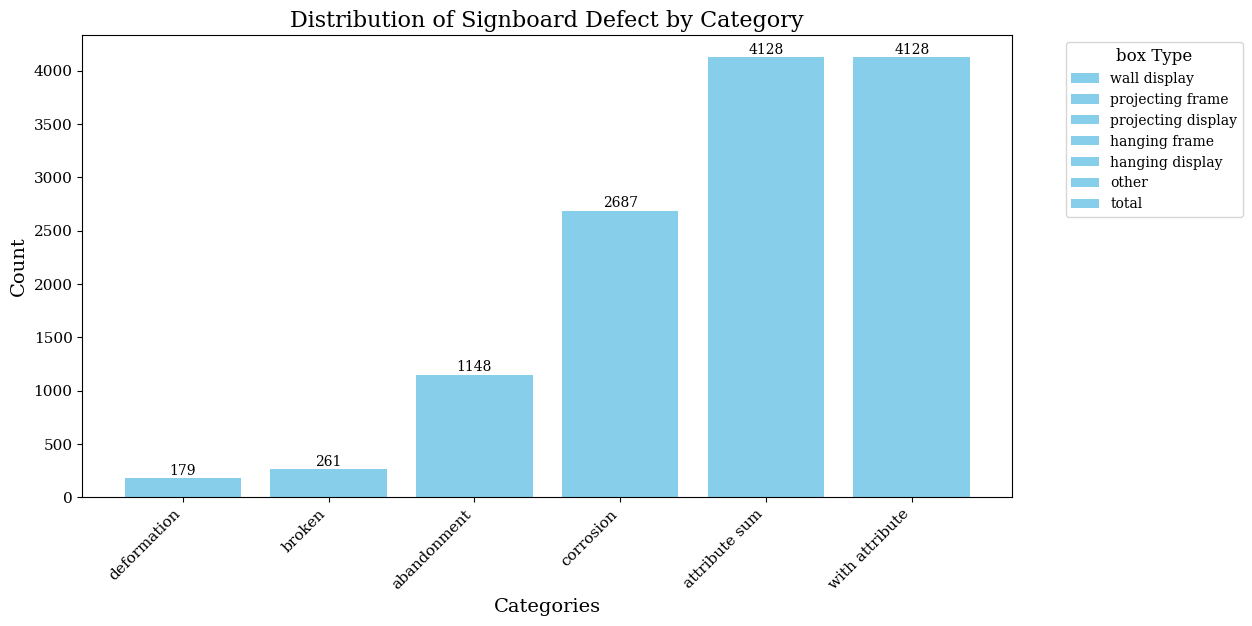

In [23]:
yolo_sta(
    gt_dir=label_v15_dir,
    result_dir=label_v15_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

label read: 100%|██████████| 7946/7946 [00:33<00:00, 236.05it/s]


get 7946 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 61808 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/labels_v16_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 61808; 有缺陷的box数: 4024; 没有缺陷的box数: 57784
总image数: 7840; 有缺陷的image数: 2715; 没有缺陷的image数: 5125
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 159   
broken                   147                 0                  43   
abandonment              883                 6                 141   
corrosion                127              1096                1319   
attribute sum           1137              1100                1596   
with attribute          1137              1100                1596   

category        hanging frame  hanging display  o

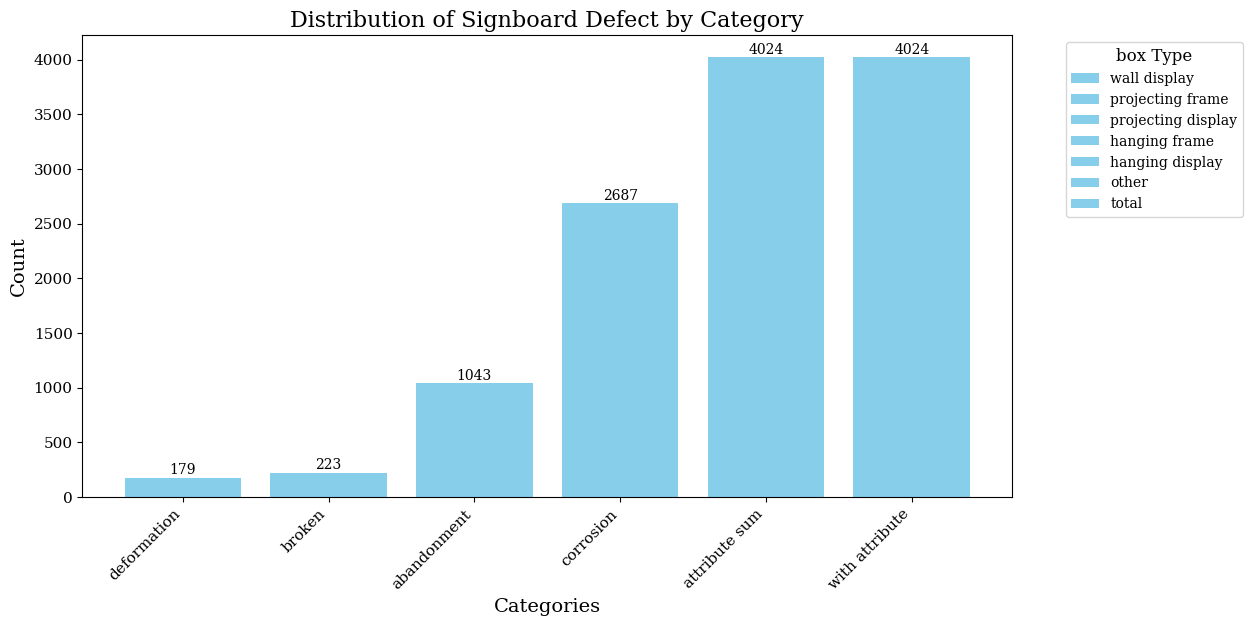

In [24]:
yolo_sta(
    gt_dir=label_v16_dir,
    result_dir=label_v16_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

In [26]:
copy_all(
    label_v16_dir,
    os.path.join(datav16_dir, 'labels'),
    image_dir,
    os.path.join(datav16_dir, 'images'),
)

copy_all: 100%|██████████| 7946/7946 [00:25<00:00, 308.55it/s]


In [27]:
output_dir = datav16_dir
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path)
copy_split(input_val_test_path, output_val_test_path)
copy_split(input_train_80p_path, output_train_80p_path)
copy_split(input_val_80p_path, output_val_80p_path)
copy_split(input_all_path, output_all_path)
copy_split(input_all_test_path, output_all_test_path)

shutil.copy(class_c6_path, os.path.join(output_dir, 'class.txt'))
shutil.copy(att_l3_path, os.path.join(output_dir, 'attribute.yaml'))

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records


'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1112_v16/attribute.yaml'

In [28]:
data_tf_pipline_new(datav16_dir, copy_list=['mseg_c5_l2'])

risk to l2: 100%|██████████| 7946/7946 [00:11<00:00, 714.66it/s]


In [29]:
output_dir = datav16_dir.replace('mseg_c6', 'mseg_c5_l2')
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path, abs_path=True)
copy_split(input_val_test_path, output_val_test_path, abs_path=True)
copy_split(input_train_80p_path, output_train_80p_path, abs_path=True)
copy_split(input_val_80p_path, output_val_80p_path, abs_path=True)
copy_split(input_all_path, output_all_path, abs_path=True)
copy_split(input_all_test_path, output_all_test_path, abs_path=True)

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records
